In [21]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [22]:
lit = pd.read_csv('../DATA/lit.csv')
san = pd.read_csv('../DATA/san.csv')

In [23]:
df = pd.merge(lit,san,on = "State/UT")
print(df.isnull().sum())
print(len(df))
df.head()

State/UT                                    0
Total Literacy                              0
Percentage with basic sanitation service    0
dtype: int64
36


,State/UT,Total Literacy,Percentage with basic sanitation service
0,Chandigarh,84.45,85.0
1,Delhi,86.95,81.1
2,Haryana,85.60,85.0
3,Himachal Pradesh,91.75,81.7
4,Jammu & Kashmir,82.25,75.7


In [24]:
df.to_csv(r"C:\Users\Anish\OneDrive\Desktop\minor\DATA\final_result.csv", index=False)

In [25]:
r = df["Total Literacy"].corr(df["Percentage with basic sanitation service"])
print("Correlation (r):", r)

Correlation (r): 0.6735673087115095


In [26]:
r_squared = r ** 2
print(r_squared)

0.45369291936486594


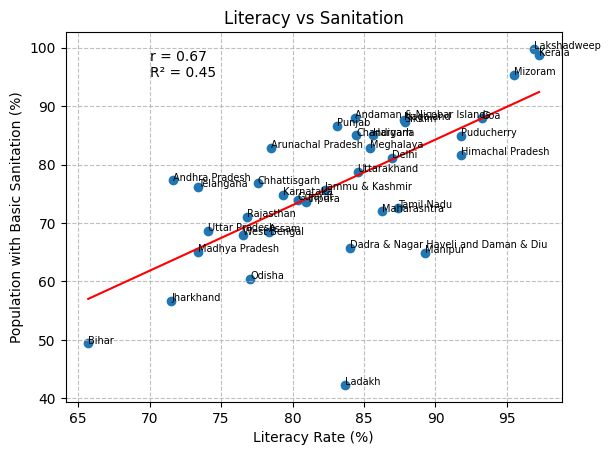

In [ ]:
plt.scatter(df["Total Literacy"], df["Percentage with basic sanitation service"])
m, b = np.polyfit(df["Total Literacy"], df["Percentage with basic sanitation service"], 1)
#plt.plot(df["Total Literacy"], m*df["Total Literacy"] + b)
x = np.linspace(df["Total Literacy"].min(), df["Total Literacy"].max(), 100)
y = m*x + b
plt.plot(x, y, color="red")
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Population with Basic Sanitation (%)")
plt.title("Literacy vs Sanitation")
plt.text(70, 95, f"r = {r:.2f}\nR² = {r**2:.2f}")
plt.grid(True, linestyle="--", alpha=0.8)
for i, txt in enumerate(df["State/UT"]):
    plt.annotate(txt,
                 (df["Total Literacy"][i],
                  df["Percentage with basic sanitation service"][i]),
                 fontsize=7)
plt.savefig("../WEBSITE1/scatter.png", dpi=300, bbox_inches="tight")
plt.show()

The Pearson correlation coefficient between literacy rate and
access to basic sanitation services across Indian states is
r = 0.67.

This indicates a moderately strong positive relationship,
suggesting that states with higher literacy levels tend to
have better sanitation access.

The coefficient of determination (R² = 0.45) shows that
approximately 45% of the variation in sanitation coverage
can be explained by differences in literacy rates.

The remaining variation is likely influenced by other factors
such as infrastructure development, economic conditions,
and government sanitation programs.

BARCHART OF BOTTOM 10 STATES WITH HIGHEST SANITATION COVERAGE

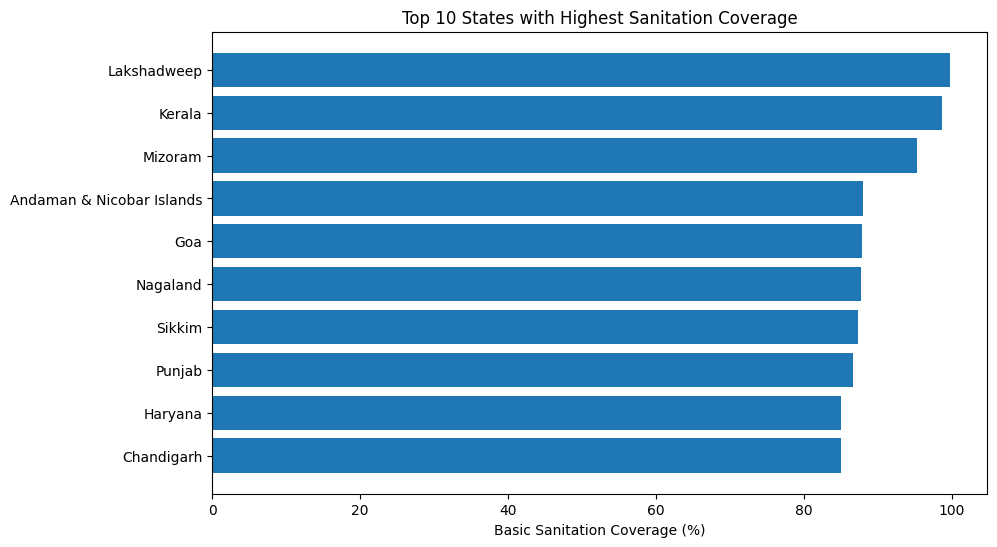

In [ ]:
top10 = df.sort_values(
    "Percentage with basic sanitation service",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["State/UT"],
    top10["Percentage with basic sanitation service"]
)

plt.xlabel("Basic Sanitation Coverage (%)")
plt.title("Top 10 States with Highest Sanitation Coverage")

plt.gca().invert_yaxis()
plt.savefig("../WEBSITE1/sanitation_top10.png", dpi=200, bbox_inches="tight")
plt.show()

BARCHART OF BOTTOM 10 STATES WITH LOWEST SANITATION COVERAGE

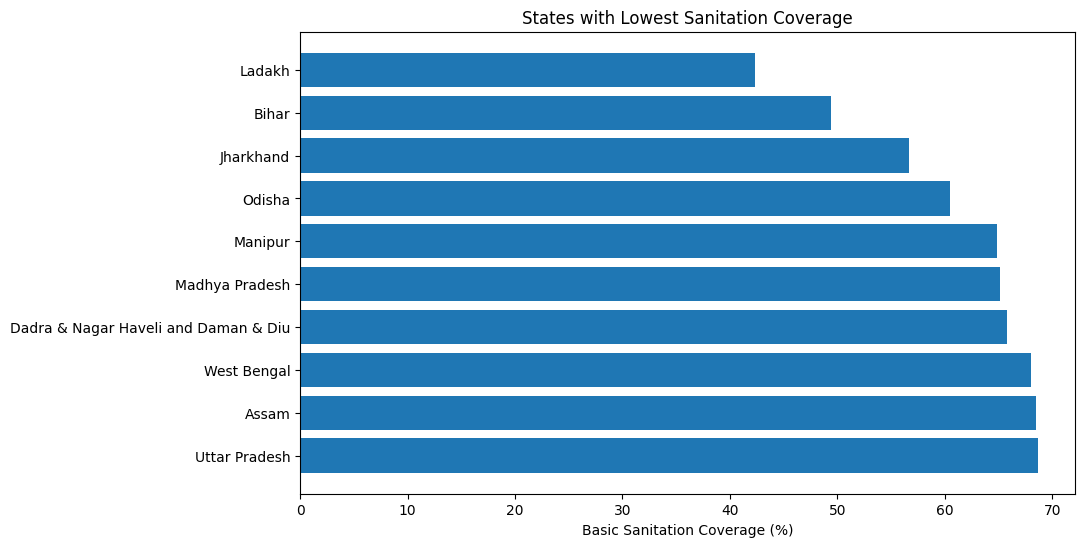

In [ ]:
bottom10 = df.sort_values(
    "Percentage with basic sanitation service"
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    bottom10["State/UT"],
    bottom10["Percentage with basic sanitation service"]
)

plt.xlabel("Basic Sanitation Coverage (%)")
plt.title("States with Lowest Sanitation Coverage")

plt.gca().invert_yaxis()
plt.savefig("../WEBSITE1/sanitation_bottom10.png", dpi=300, bbox_inches="tight")
plt.show()